In [90]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)

In [91]:
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "lines.linewidth": 2,
    "errorbar.capsize": 4
})

In [92]:
BENCH_DIR = "../cuda_engine/benchmarks"
OUT_DIR = "../plots"

os.makedirs(OUT_DIR, exist_ok=True)
print(f"Directory benchmarks: '{BENCH_DIR}'")
print(f"Directory output plot: '{OUT_DIR}'")

Directory benchmarks: '../cuda_engine/benchmarks'
Directory output plot: '../plots'


In [93]:
df_batching = pd.read_csv(os.path.join(BENCH_DIR, "non_batching_vs_batching.csv"))
df_scaling  = pd.read_csv(os.path.join(BENCH_DIR, "latency_batch_scaling.csv"))
df_ablation = pd.read_csv(os.path.join(BENCH_DIR, "ablation_study.csv"))
df_layers   = pd.read_csv(os.path.join(BENCH_DIR, "layer_breakdown.csv"))
df_preds    = pd.read_csv(os.path.join(BENCH_DIR, "full_test_predictions.csv"))

print(f"Caricati con successo da '{BENCH_DIR}':")
print(f" - Non-Batching vs Batching : {len(df_batching)} configurazioni")
print(f" - Batch Scaling Sweep      : {len(df_scaling)} batch sizes")
print(f" - Ablation Study (v0-v1-v2): {len(df_ablation)} batch sizes")
print(f" - Layer Breakdown Profiling: {len(df_layers)} stages")
print(f" - Full Dataset Predictions : {len(df_preds):,} campioni")

Caricati con successo da '../cuda_engine/benchmarks':
 - Non-Batching vs Batching : 2 configurazioni
 - Batch Scaling Sweep      : 9 batch sizes
 - Ablation Study (v0-v1-v2): 4 batch sizes
 - Layer Breakdown Profiling: 7 stages
 - Full Dataset Predictions : 56,580 campioni


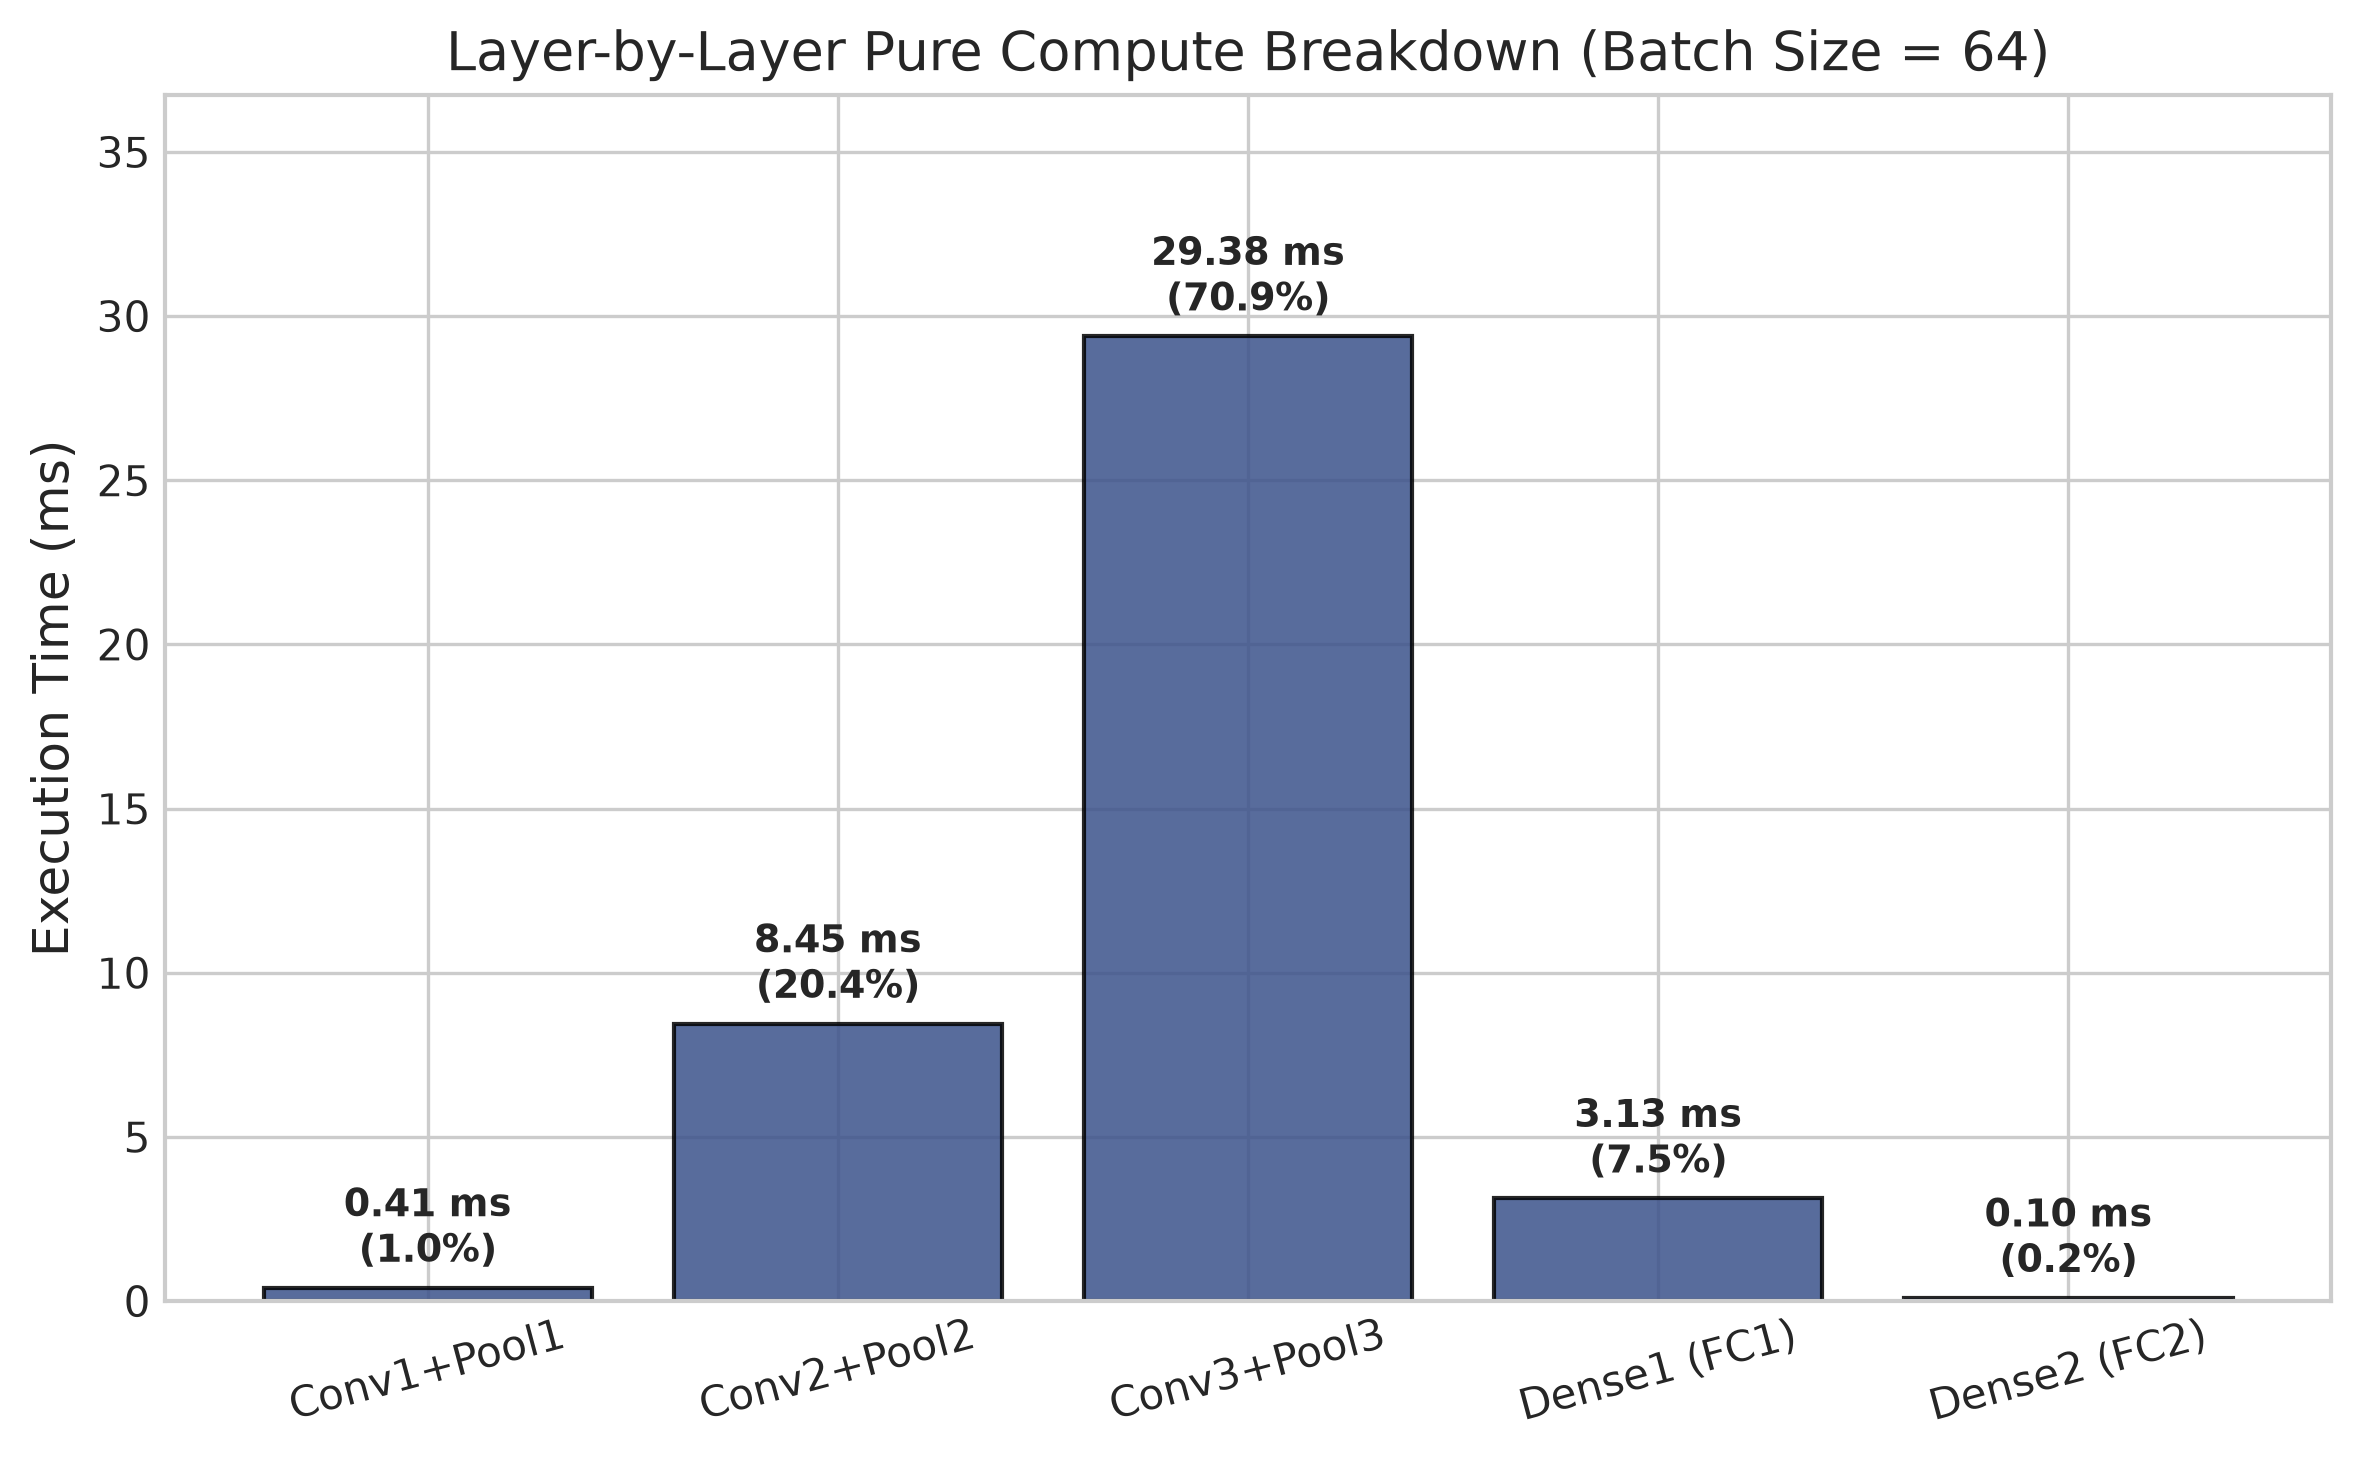

In [94]:
df_compute = df_layers[~df_layers["stage"].isin(["h2d", "d2h"])].copy()
stage_names = ["Conv1+Pool1", "Conv2+Pool2", "Conv3+Pool3", "Dense1 (FC1)", "Dense2 (FC2)"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(stage_names, df_compute["latency_ms"], color="#3b528b", edgecolor="black", alpha=0.85)

for bar, pct in zip(bars, df_compute["pct_compute"]):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.4, f"{yval:.2f} ms\n({pct:.1f}%)", 
            ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_ylabel("Execution Time (ms)")
ax.set_title("Layer-by-Layer Pure Compute Breakdown (Batch Size = 64)")
ax.set_ylim(0, df_compute["latency_ms"].max() * 1.25)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "01_layer_breakdown_bottleneck.png"))
plt.show()

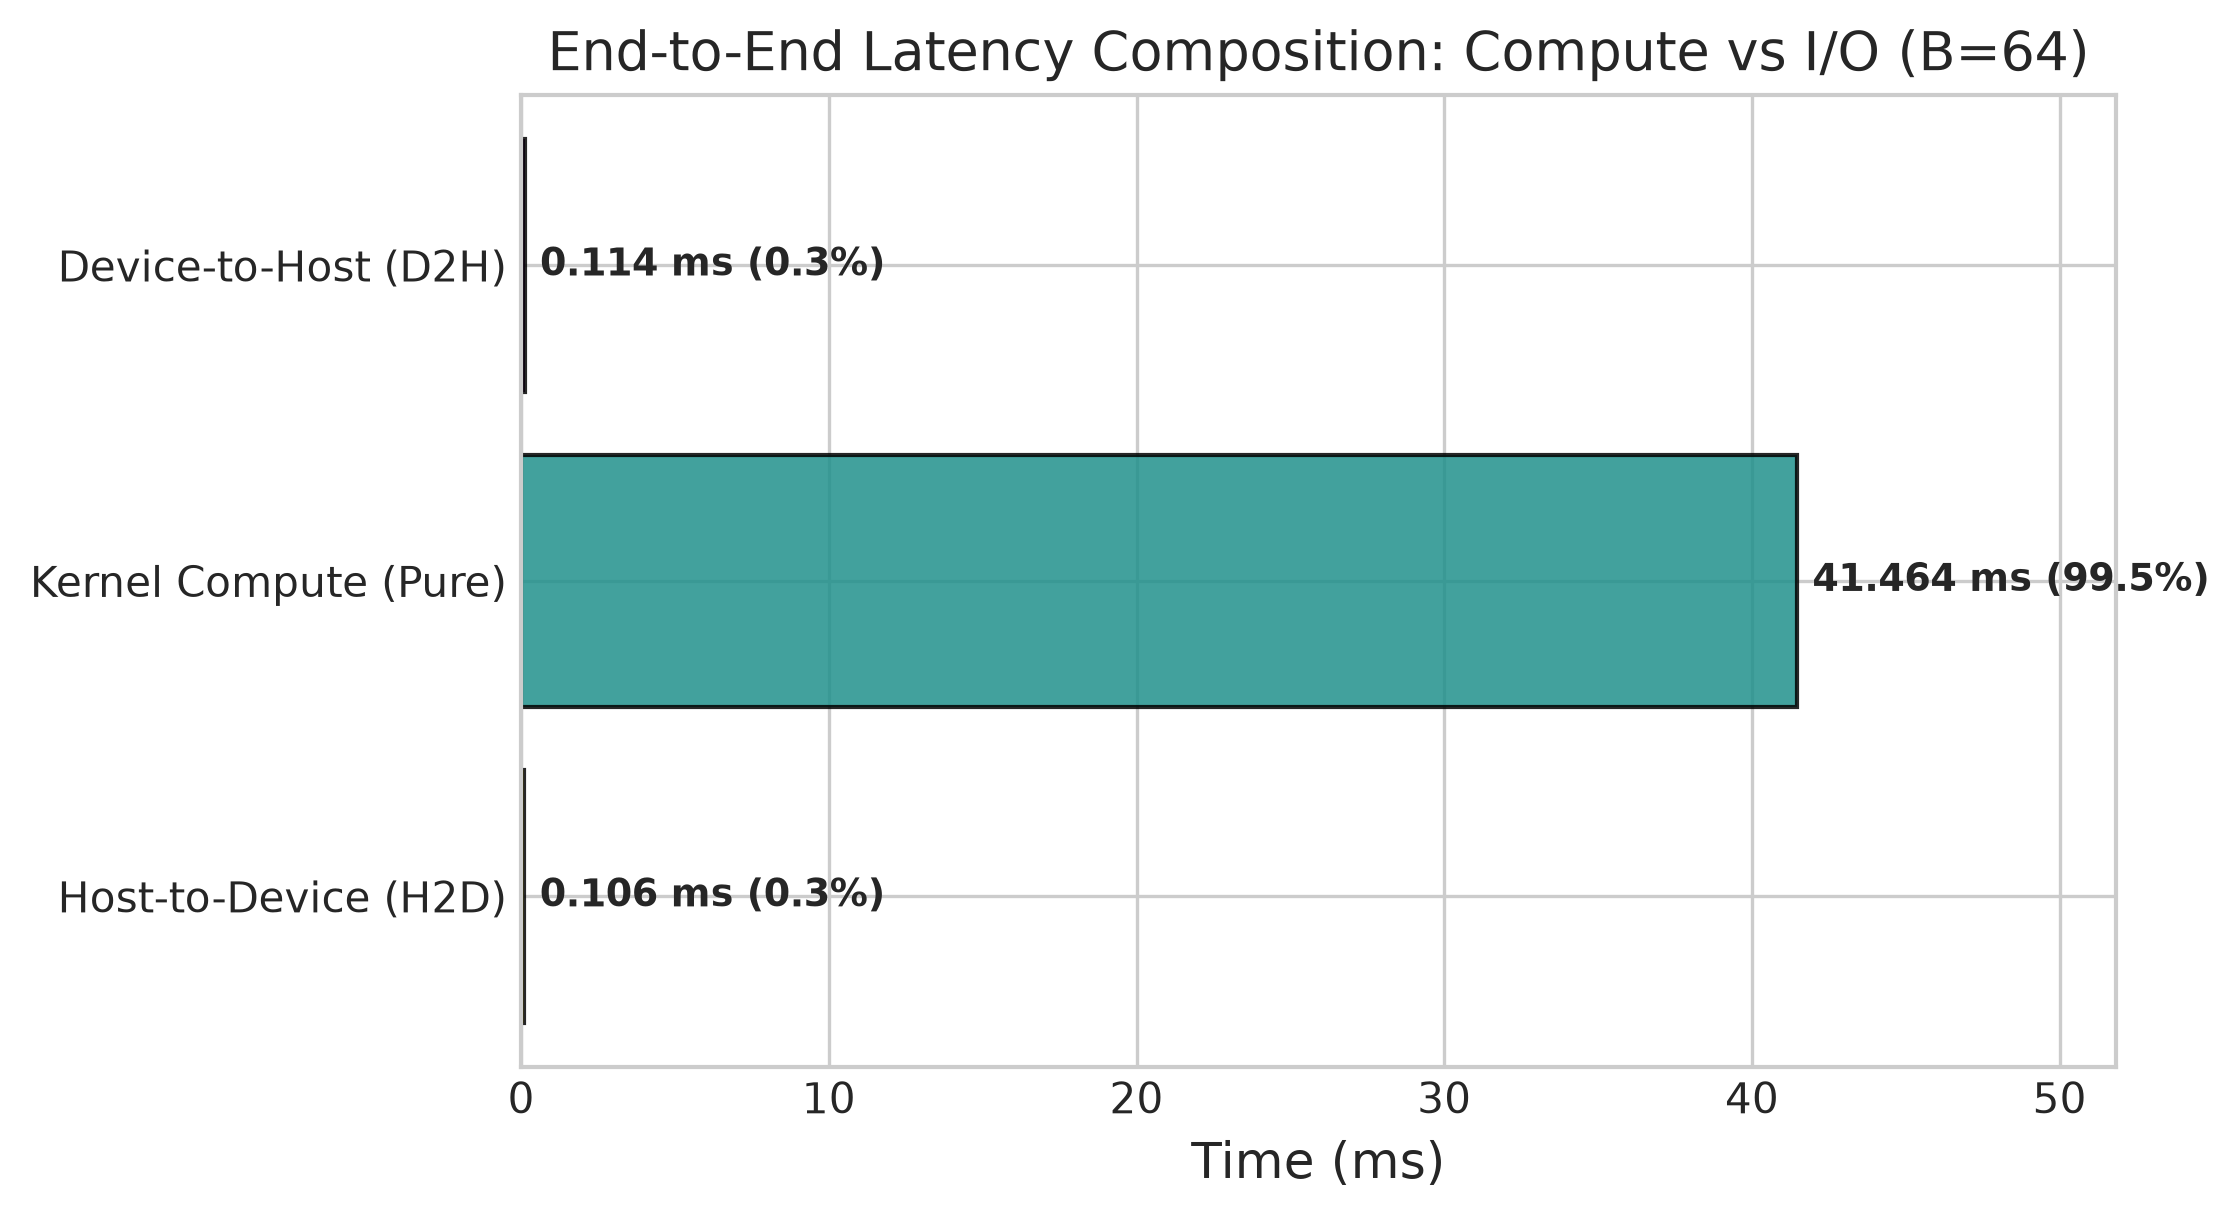

In [95]:
t_h2d = df_layers[df_layers["stage"] == "h2d"]["latency_ms"].values[0]
t_d2h = df_layers[df_layers["stage"] == "d2h"]["latency_ms"].values[0]
t_comp = df_compute["latency_ms"].sum()
total_e2e = t_h2d + t_comp + t_d2h

fig, ax = plt.subplots(figsize=(7.5, 4.2))
categories = ["Host-to-Device (H2D)", "Kernel Compute (Pure)", "Device-to-Host (D2H)"]
times = [t_h2d, t_comp, t_d2h]
colors = ["#fde725", "#21918c", "#440154"]

bars = ax.barh(categories, times, color=colors, edgecolor="black", alpha=0.85)
for bar, val in zip(bars, times):
    pct = (val / total_e2e) * 100.0
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2.0, f"{val:.3f} ms ({pct:.1f}%)", 
            ha="left", va="center", fontsize=9, fontweight="bold")

ax.set_xlabel("Time (ms)")
ax.set_title("End-to-End Latency Composition: Compute vs I/O (B=64)")
ax.set_xlim(0, max(times) * 1.25)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "02_compute_vs_transfer.png"))
plt.show()

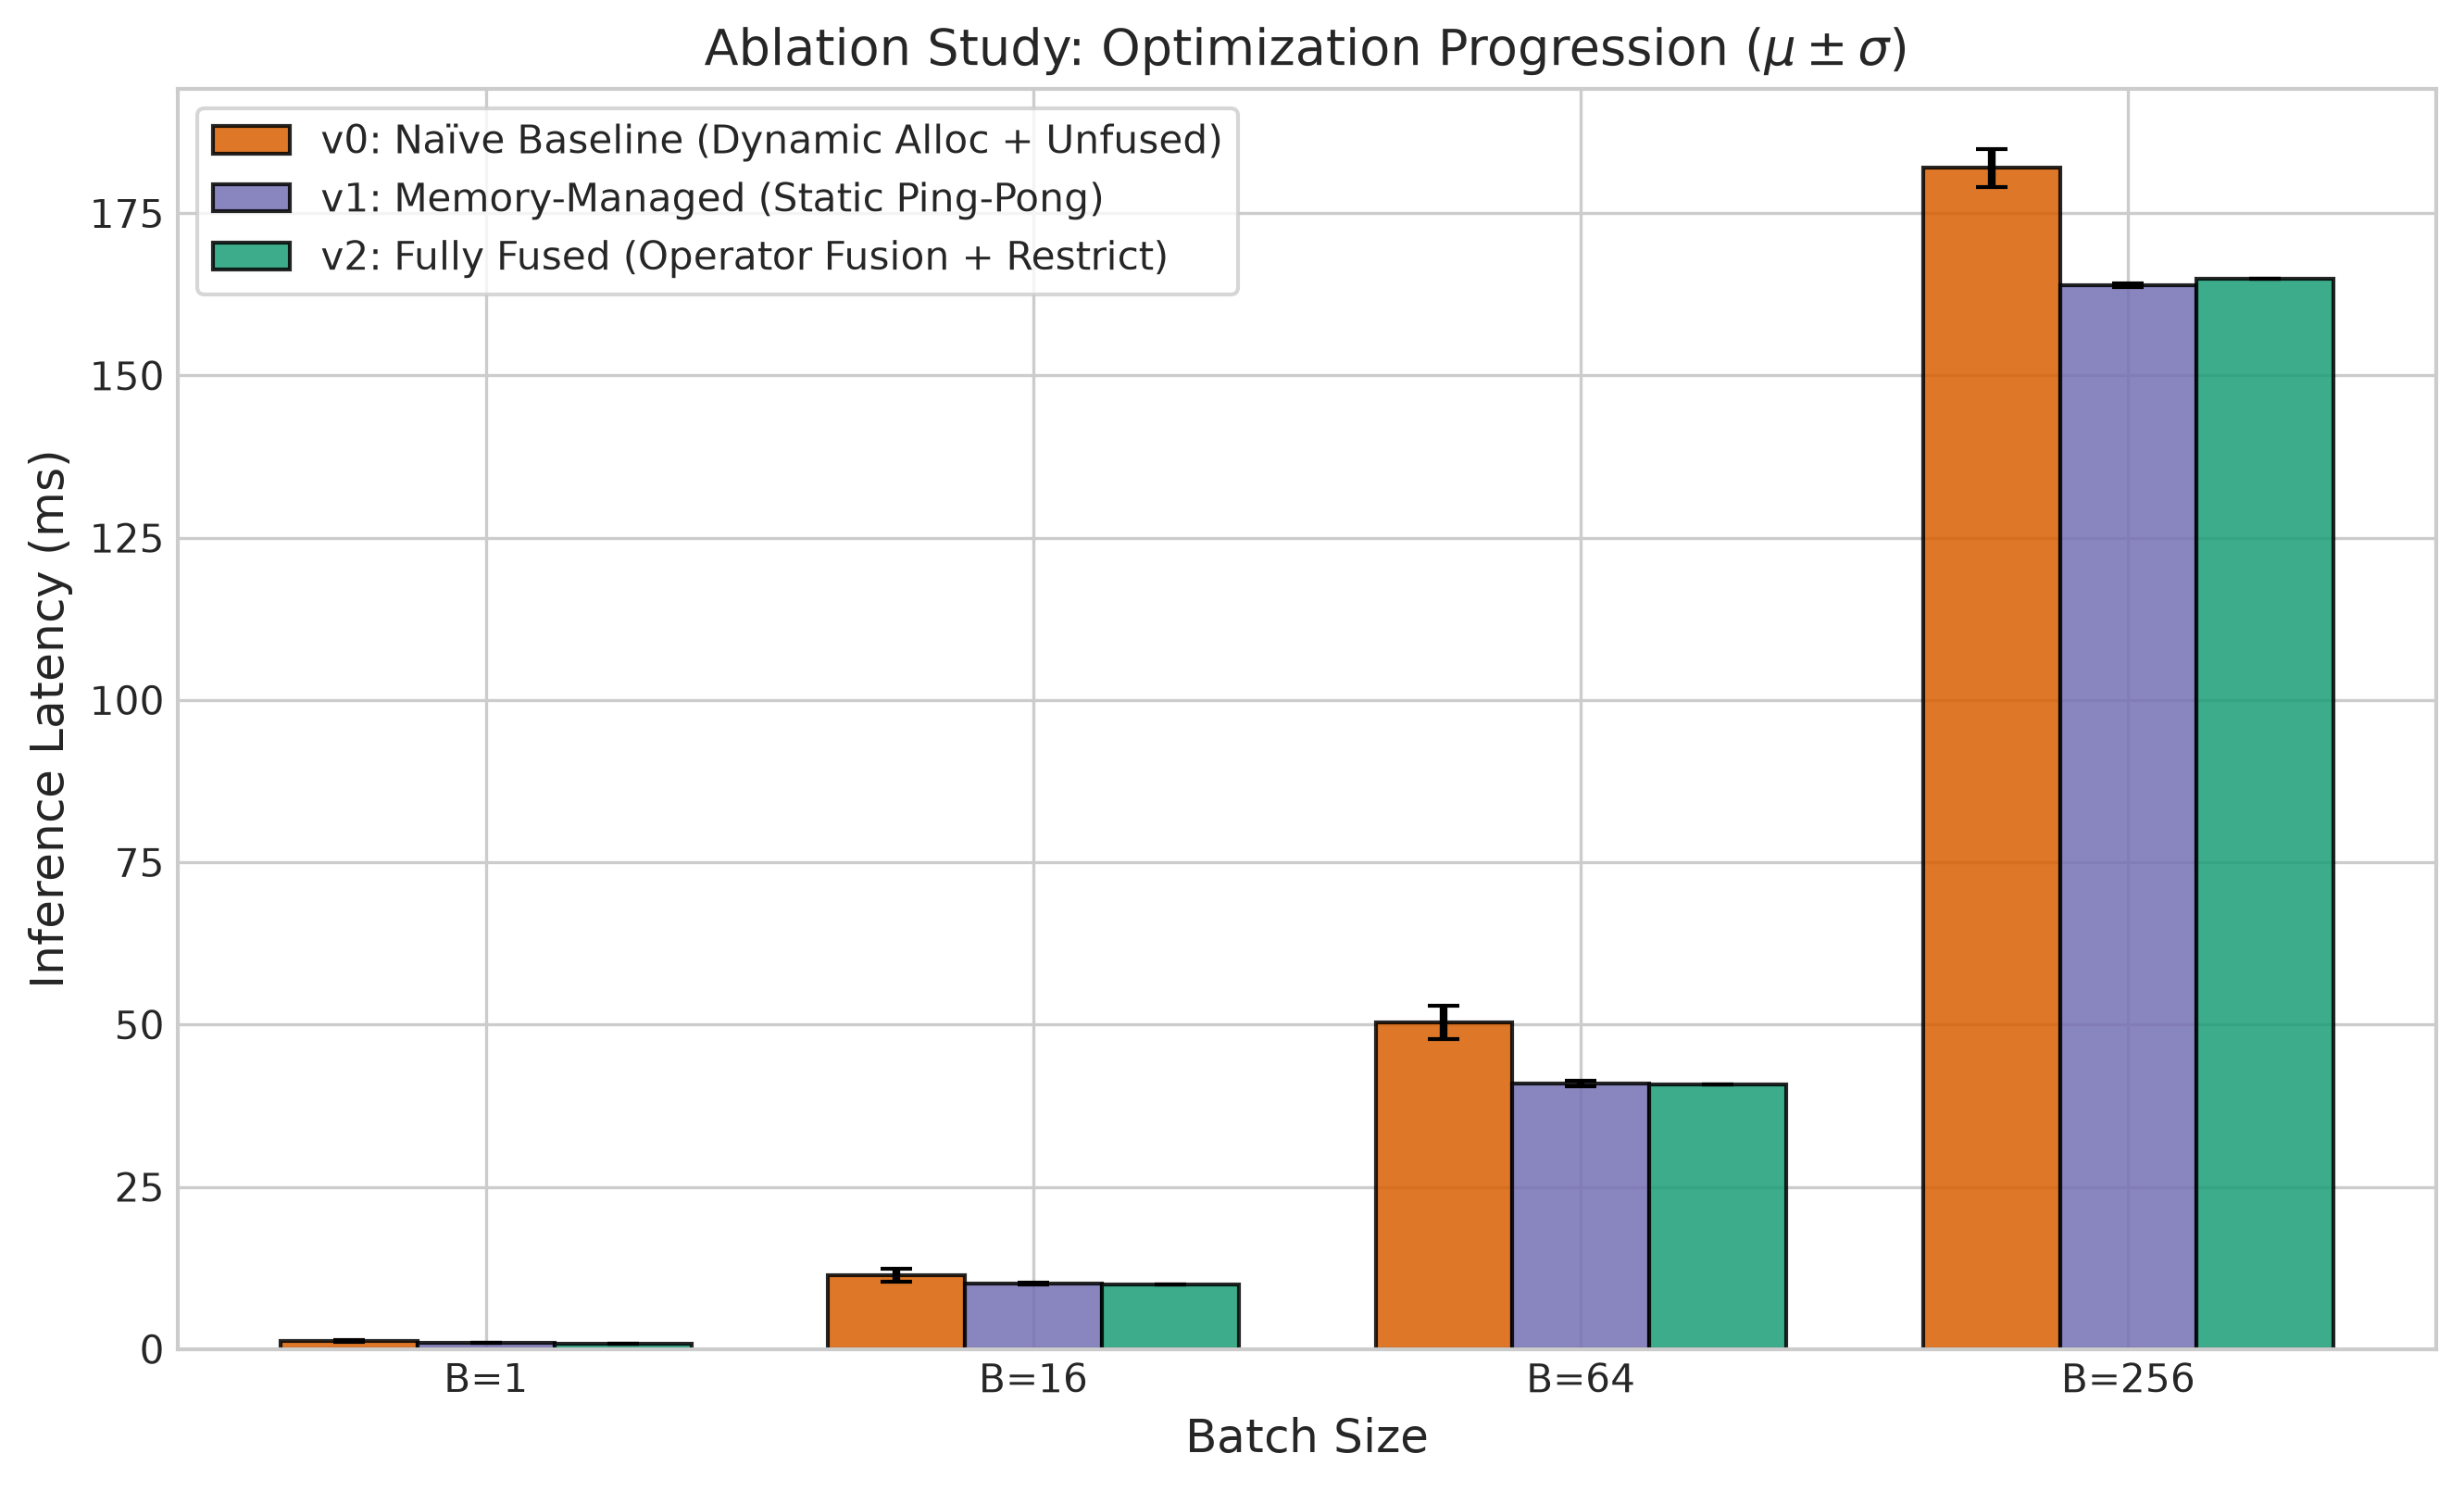

In [96]:
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(df_ablation))
width = 0.25

b0 = ax.bar(x - width, df_ablation["v0_naive_mean_ms"], width, yerr=df_ablation["v0_naive_std_ms"],
            label="v0: Naïve Baseline (Dynamic Alloc + Unfused)", color="#d95f02", edgecolor="black", alpha=0.85)
b1 = ax.bar(x, df_ablation["v1_mem_mean_ms"], width, yerr=df_ablation["v1_mem_std_ms"],
            label="v1: Memory-Managed (Static Ping-Pong)", color="#7570b3", edgecolor="black", alpha=0.85)
b2 = ax.bar(x + width, df_ablation["v2_fused_mean_ms"], width, yerr=df_ablation["v2_fused_std_ms"],
            label="v2: Fully Fused (Operator Fusion + Restrict)", color="#1b9e77", edgecolor="black", alpha=0.85)

ax.set_xlabel("Batch Size")
ax.set_ylabel("Inference Latency (ms)")
ax.set_title("Ablation Study: Optimization Progression ($\mu \pm \sigma$)")
ax.set_xticks(x)
ax.set_xticklabels([f"B={b}" for b in df_ablation["batch_size"]])
ax.legend(frameon=True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "03_ablation_study_comparison.png"))
plt.show()

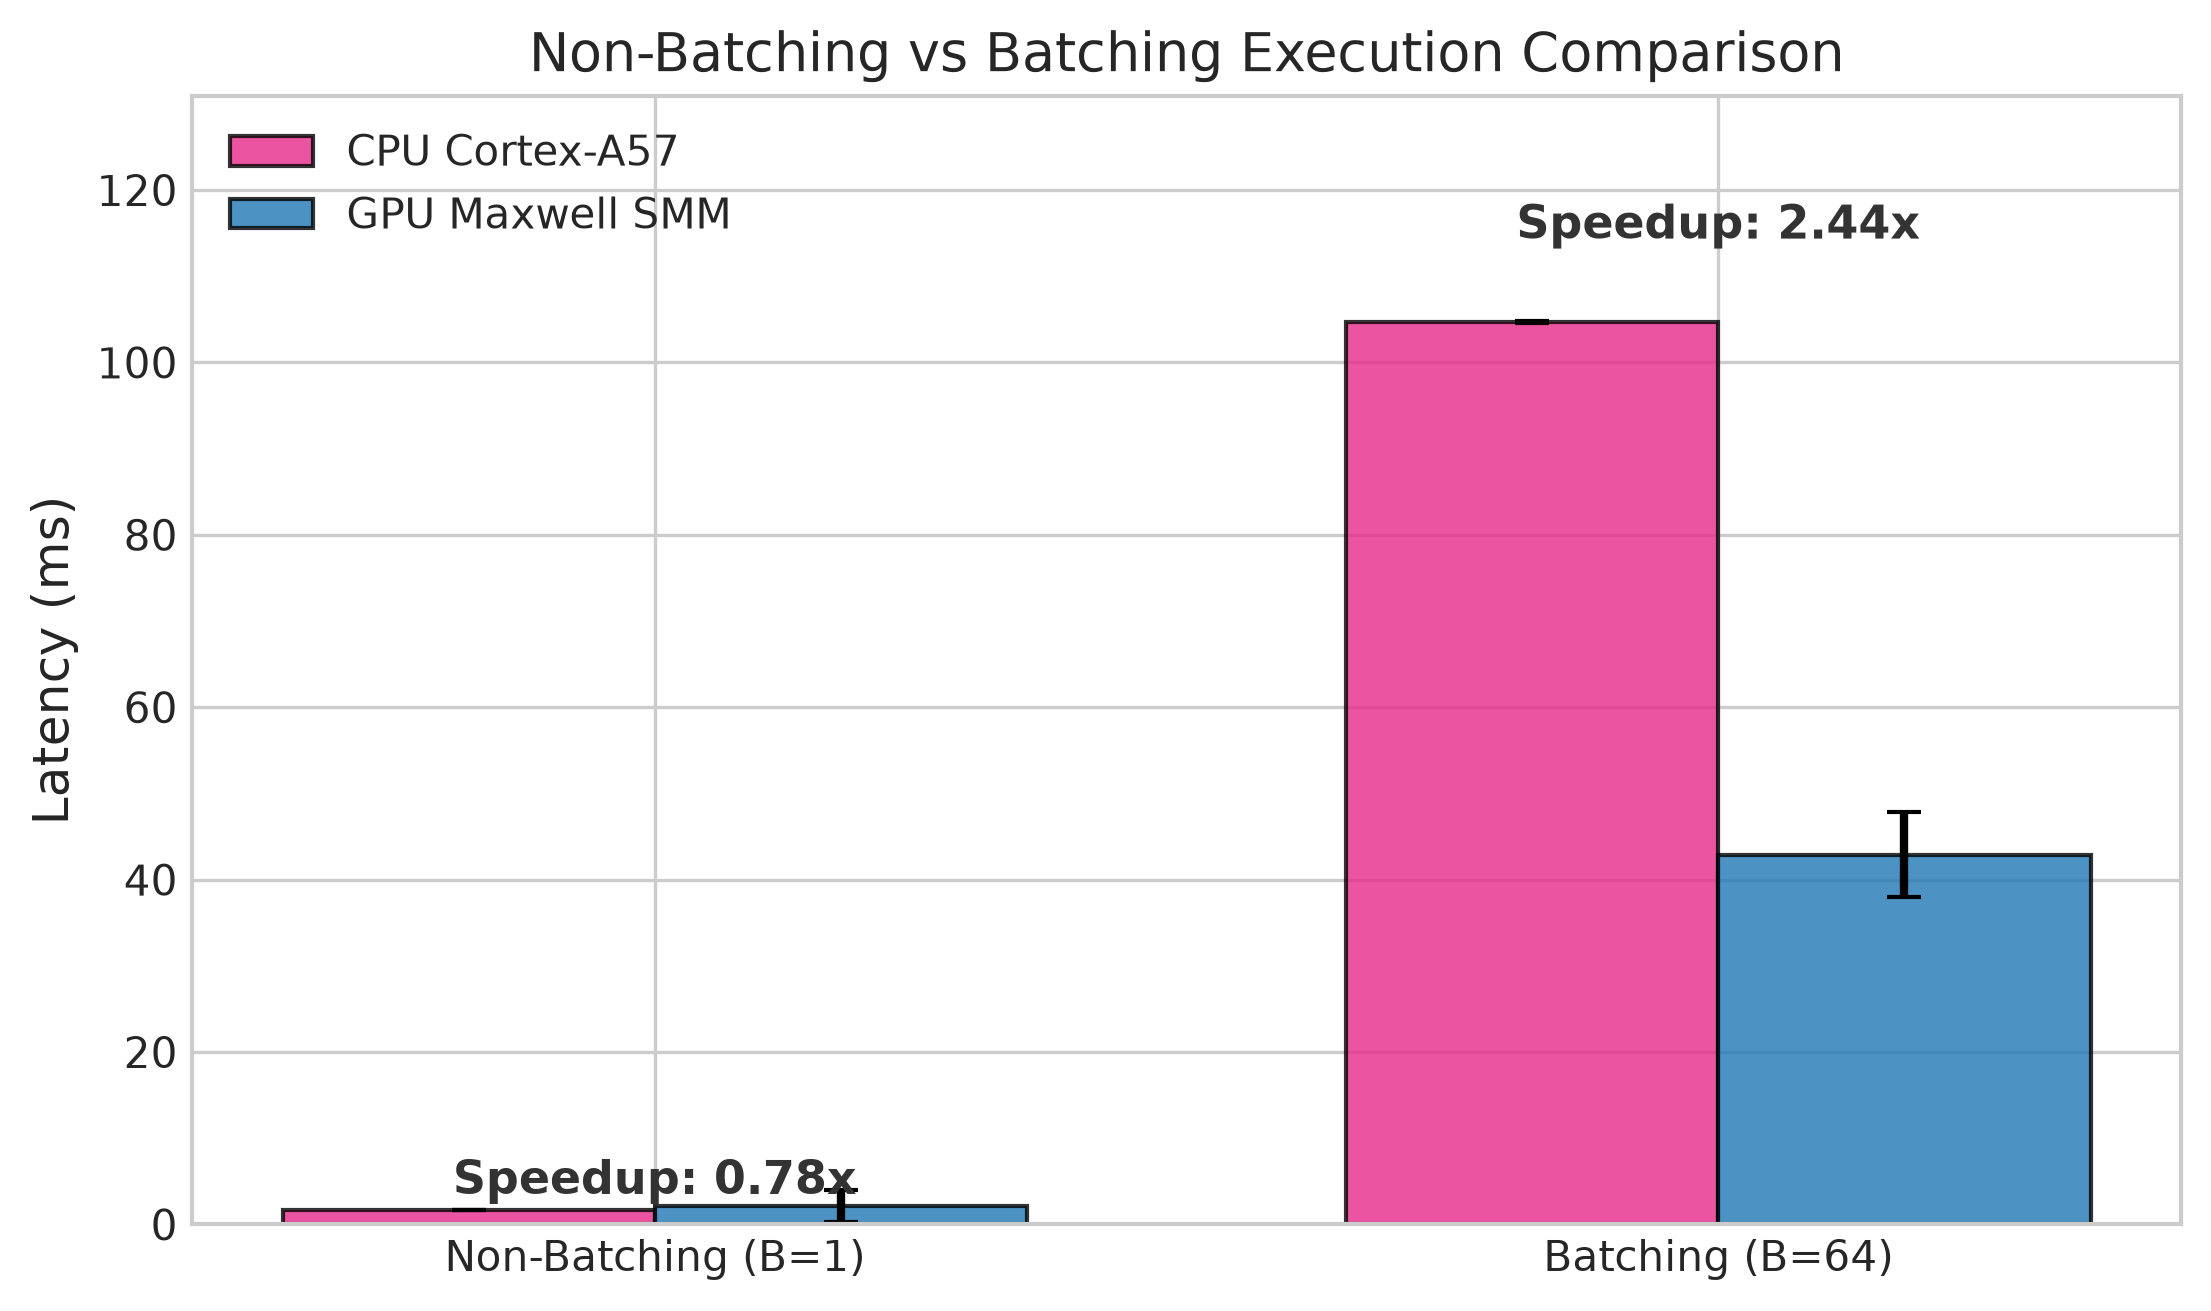

In [97]:
fig, ax1 = plt.subplots(figsize=(7.5, 4.5))
x_nb = np.arange(len(df_batching))
w = 0.35

ax1.bar(x_nb - w/2, df_batching["cpu_lat_mean_ms"], w, yerr=df_batching["cpu_lat_std_ms"],
        label="CPU Cortex-A57", color="#e7298a", edgecolor="black", alpha=0.8)
ax1.bar(x_nb + w/2, df_batching["gpu_lat_mean_ms"], w, yerr=df_batching["gpu_lat_std_ms"],
        label="GPU Maxwell SMM", color="#1f78b4", edgecolor="black", alpha=0.8)

ax1.set_ylabel("Latency (ms)")
ax1.set_xticks(x_nb)
ax1.set_xticklabels([f"Non-Batching (B=1)", f"Batching (B=64)"])
ax1.set_title("Non-Batching vs Batching Execution Comparison")
ax1.legend(loc="upper left")

for idx, r in df_batching.iterrows():
    ax1.text(idx, max(r["cpu_lat_mean_ms"], r["gpu_lat_mean_ms"]) * 1.08, 
             f"Speedup: {r['speedup']:.2f}x", ha="center", va="bottom", fontweight="bold", color="#333333")

ax1.set_ylim(0, df_batching["cpu_lat_mean_ms"].max() * 1.25)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "04_non_batching_vs_batching.png"))
plt.show()

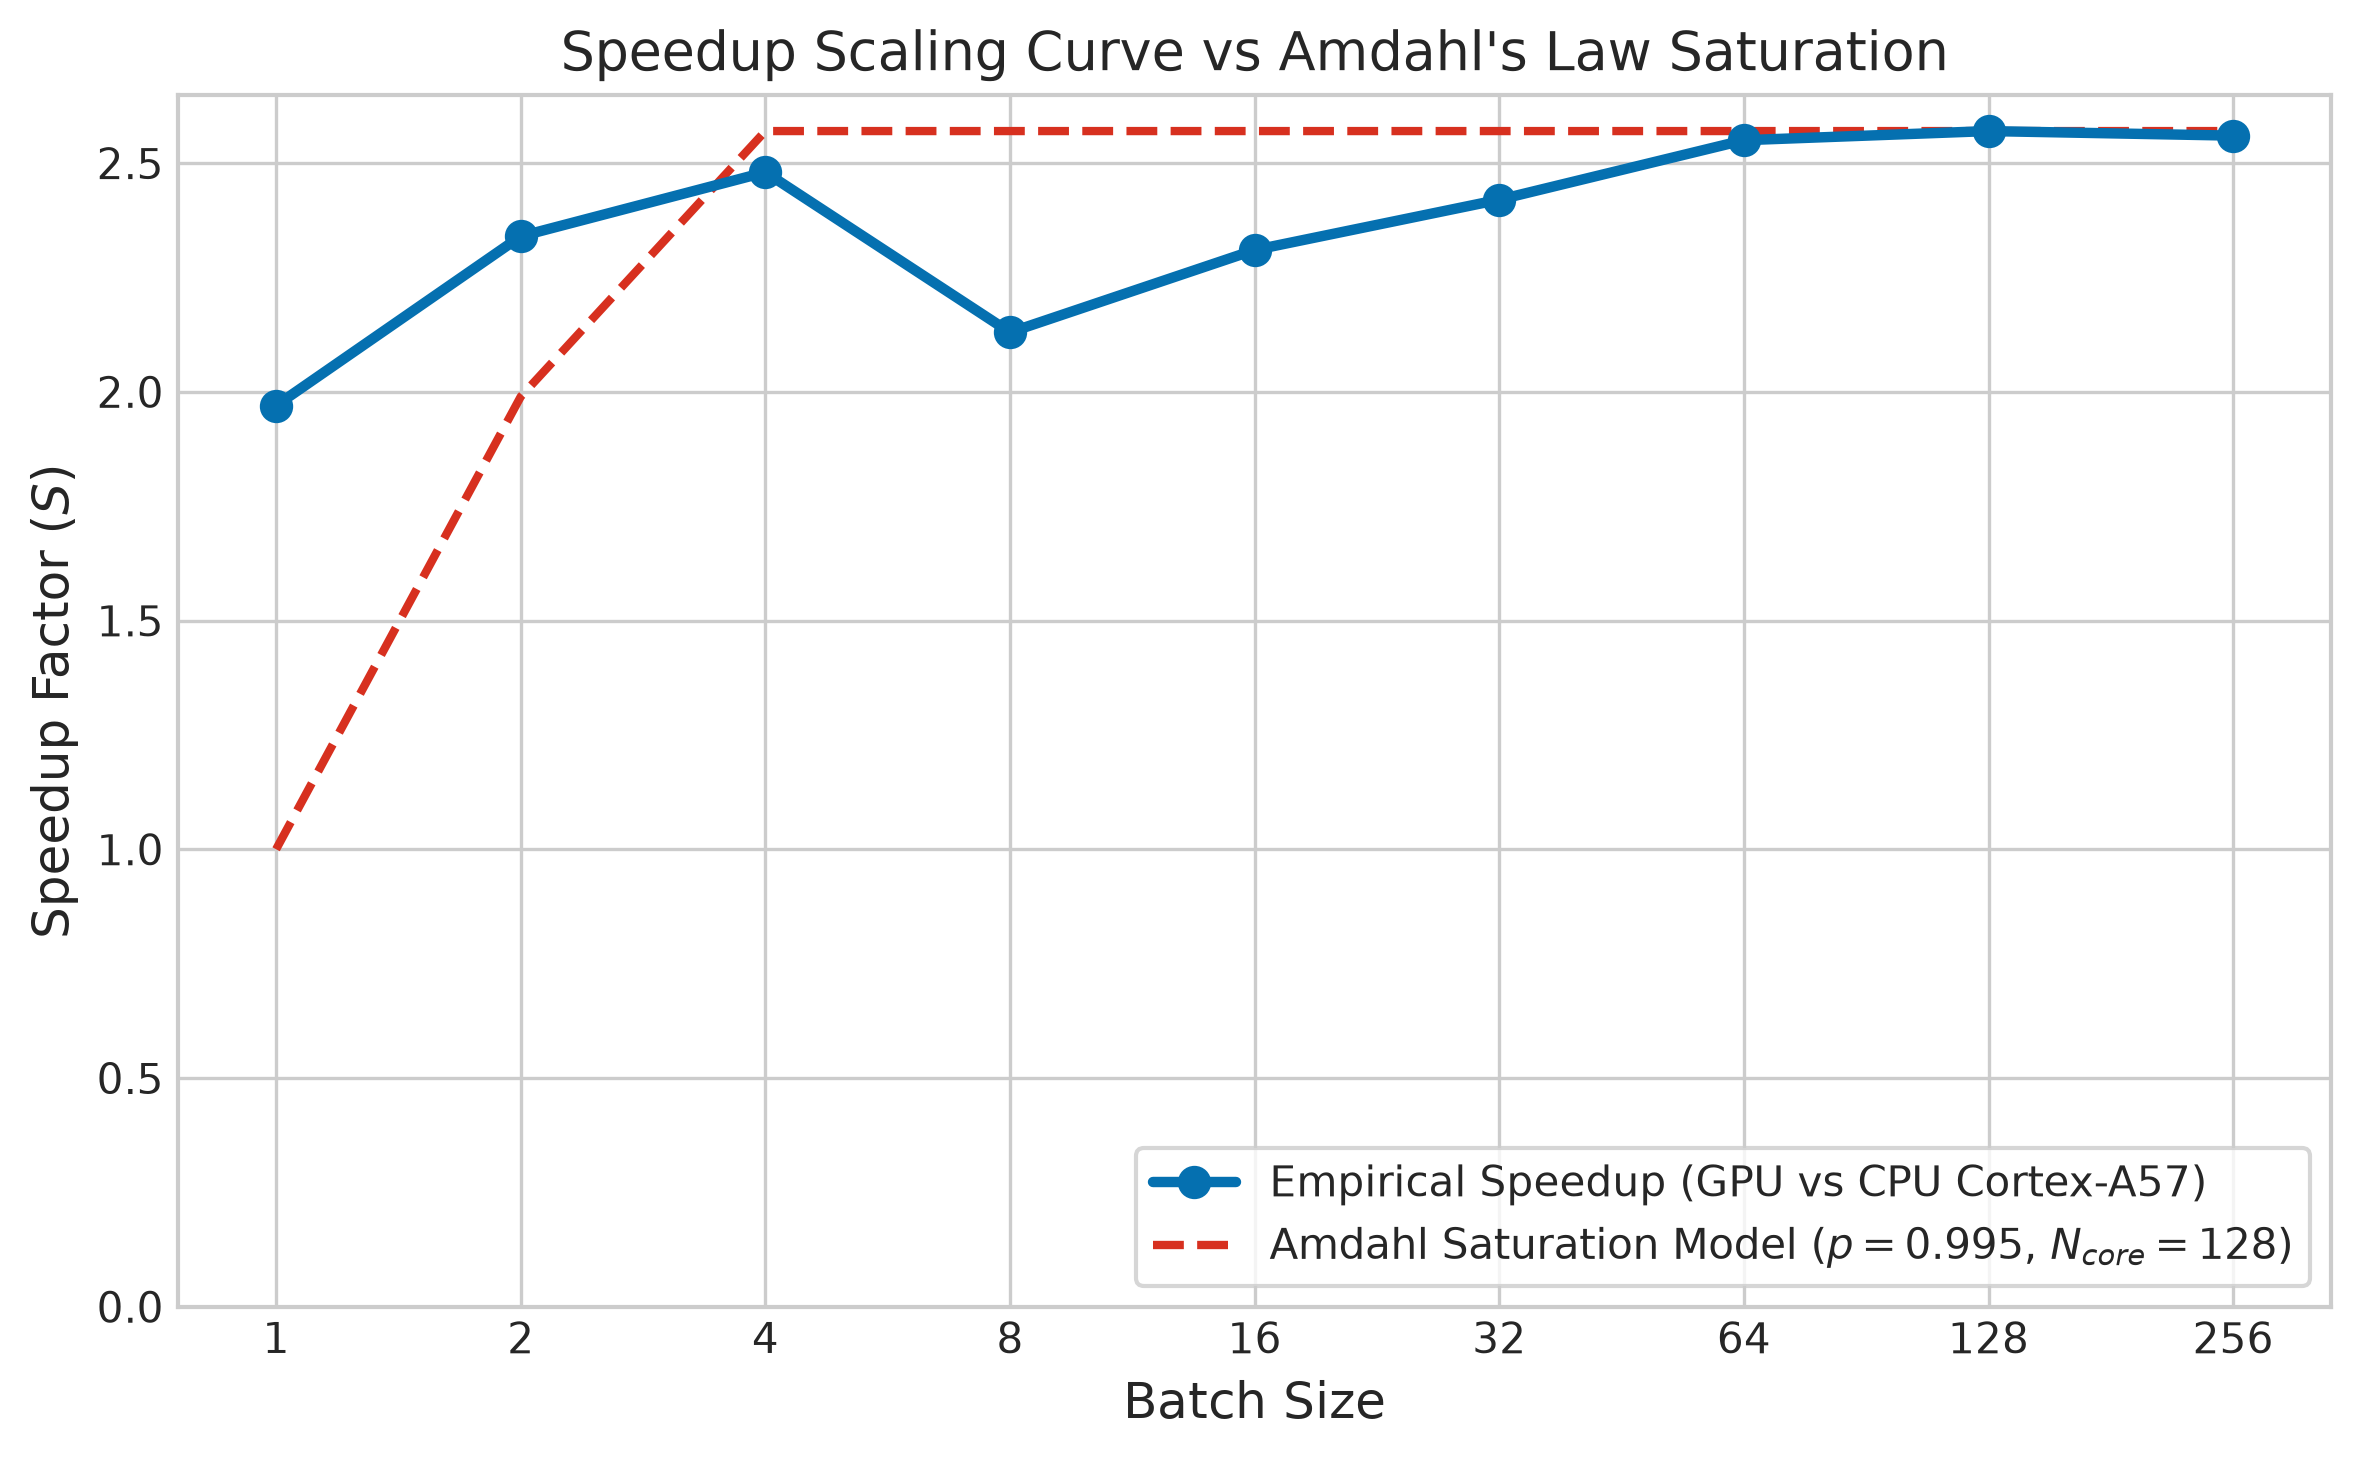

In [98]:
p_parallel = t_comp / total_e2e
batches = df_scaling["batch_size"].values

def amdahl_law(n, p):
    return 1.0 / ((1.0 - p) + (p / n))

amdahl_ideal = [amdahl_law(min(b, 128), p_parallel) for b in batches]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(df_scaling["batch_size"], df_scaling["speedup"], "o-", color="#0570b0", 
        linewidth=2.5, markersize=7, label="Empirical Speedup (GPU vs CPU Cortex-A57)", zorder=3)

ax.plot(df_scaling["batch_size"], [min(s, df_scaling["speedup"].max()) for s in amdahl_ideal], 
        "--", color="#d7301f", linewidth=2, label=f"Amdahl Saturation Model ($p={p_parallel:.3f}$, $N_{{core}}=128$)")

ax.set_xscale("log", base=2)
ax.set_xlabel("Batch Size")
ax.set_ylabel("Speedup Factor ($S$)")
ax.set_title("Speedup Scaling Curve vs Amdahl's Law Saturation")
ax.set_xticks(batches)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_ylim(bottom=0)
ax.legend(frameon=True, loc="lower right")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "05_speedup_scaling_amdahl.png"))
plt.show()

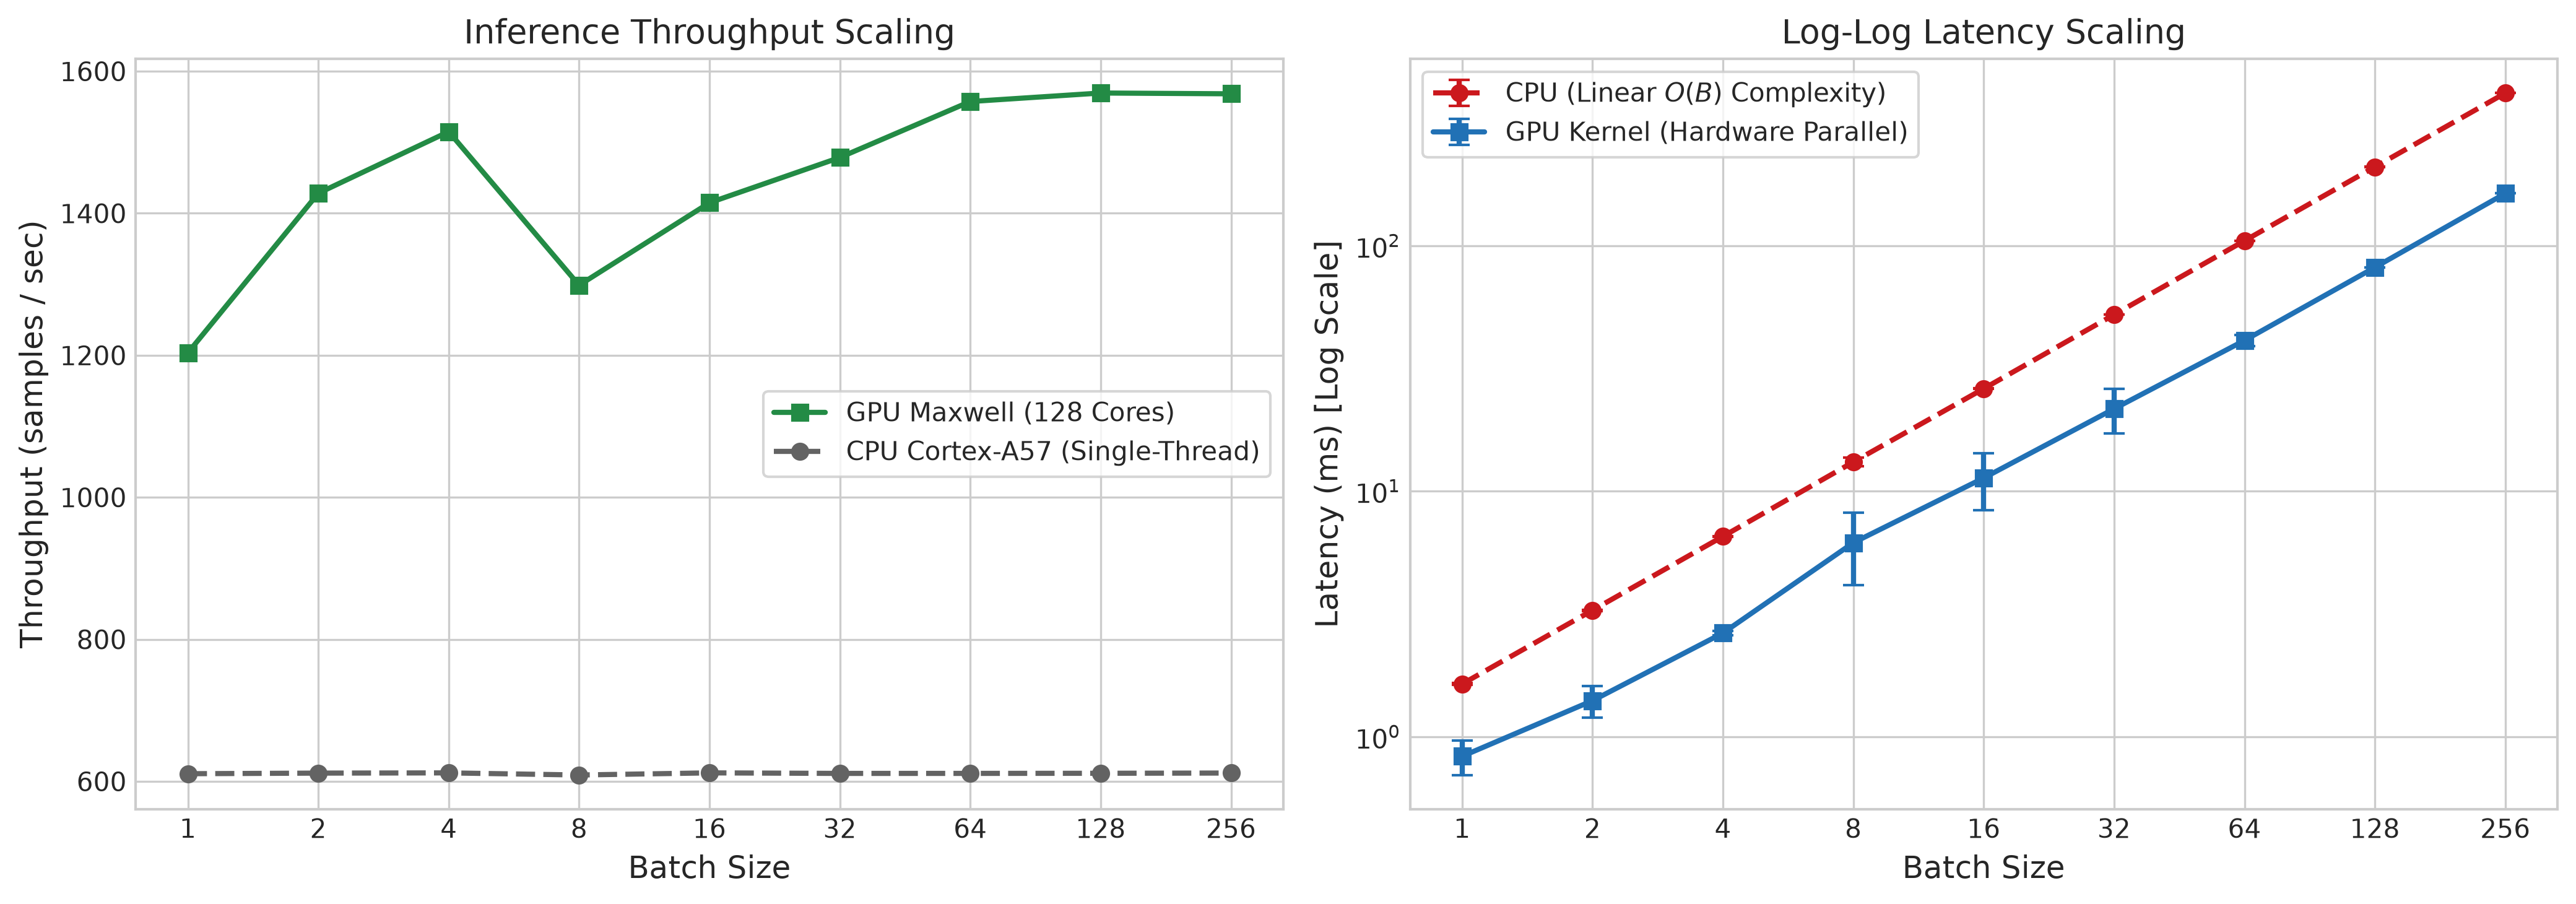

In [99]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Throughput Scaling
ax1.plot(df_scaling["batch_size"], df_scaling["gpu_throughput_sps"], "s-", color="#238b45", label="GPU Maxwell (128 Cores)")
ax1.plot(df_scaling["batch_size"], df_scaling["cpu_throughput_sps"], "o--", color="#636363", label="CPU Cortex-A57 (Single-Thread)")
ax1.set_xscale("log", base=2)
ax1.set_xlabel("Batch Size")
ax1.set_ylabel("Throughput (samples / sec)")
ax1.set_title("Inference Throughput Scaling")
ax1.set_xticks(df_scaling["batch_size"])
ax1.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax1.legend(frameon=True)

# 2. Log-Log Latency
ax2.errorbar(df_scaling["batch_size"], df_scaling["cpu_lat_mean_ms"], yerr=df_scaling["cpu_lat_std_ms"], 
             fmt="o--", color="#cb181d", label="CPU (Linear $O(B)$ Complexity)")
ax2.errorbar(df_scaling["batch_size"], df_scaling["gpu_kernel_lat_mean_ms"], yerr=df_scaling["gpu_kernel_lat_std_ms"], 
             fmt="s-", color="#2171b5", label="GPU Kernel (Hardware Parallel)")
ax2.set_xscale("log", base=2)
ax2.set_yscale("log")
ax2.set_xlabel("Batch Size")
ax2.set_ylabel("Latency (ms) [Log Scale]")
ax2.set_title("Log-Log Latency Scaling")
ax2.set_xticks(df_scaling["batch_size"])
ax2.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax2.legend(frameon=True)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "06_07_throughput_and_loglog.png"))
plt.show()

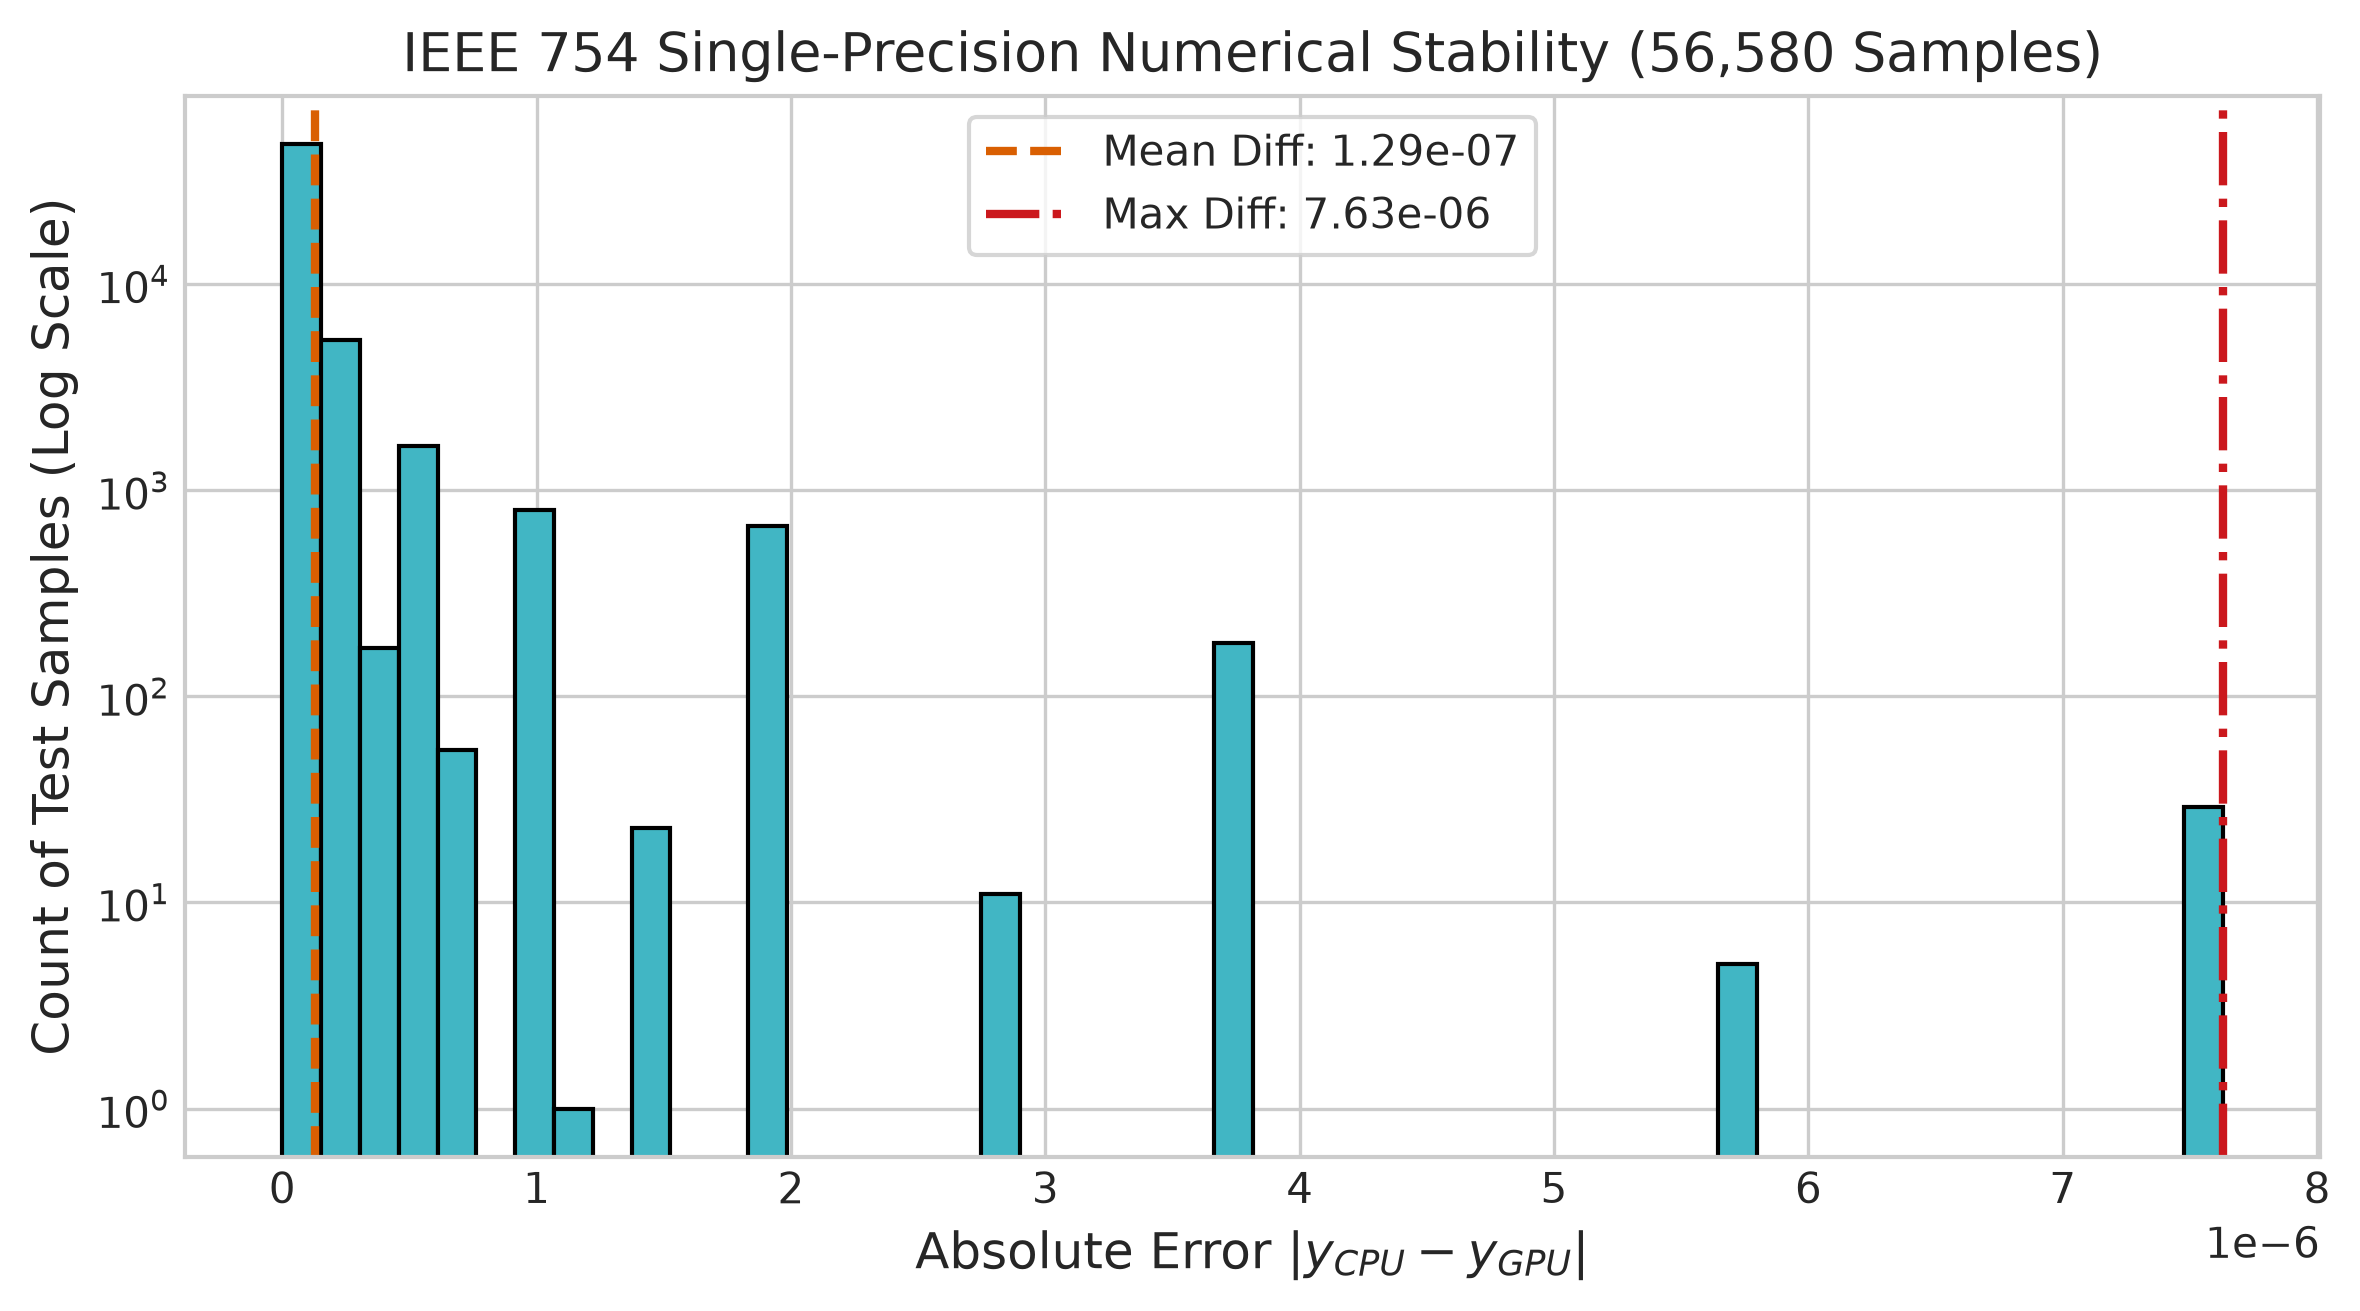

In [100]:
diffs = df_preds["abs_diff"]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(diffs, bins=50, color="#41b6c4", edgecolor="black", log=True)
ax.axvline(diffs.mean(), color="#d95f02", linestyle="--", label=f"Mean Diff: {diffs.mean():.2e}")
ax.axvline(diffs.max(), color="#cb181d", linestyle="-.", label=f"Max Diff: {diffs.max():.2e}")

ax.set_xlabel("Absolute Error $|y_{CPU} - y_{GPU}|$")
ax.set_ylabel("Count of Test Samples (Log Scale)")
ax.set_title(f"IEEE 754 Single-Precision Numerical Stability ({len(df_preds):,} Samples)")
ax.legend(frameon=True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "08_fp32_numerical_stability.png"))
plt.show()

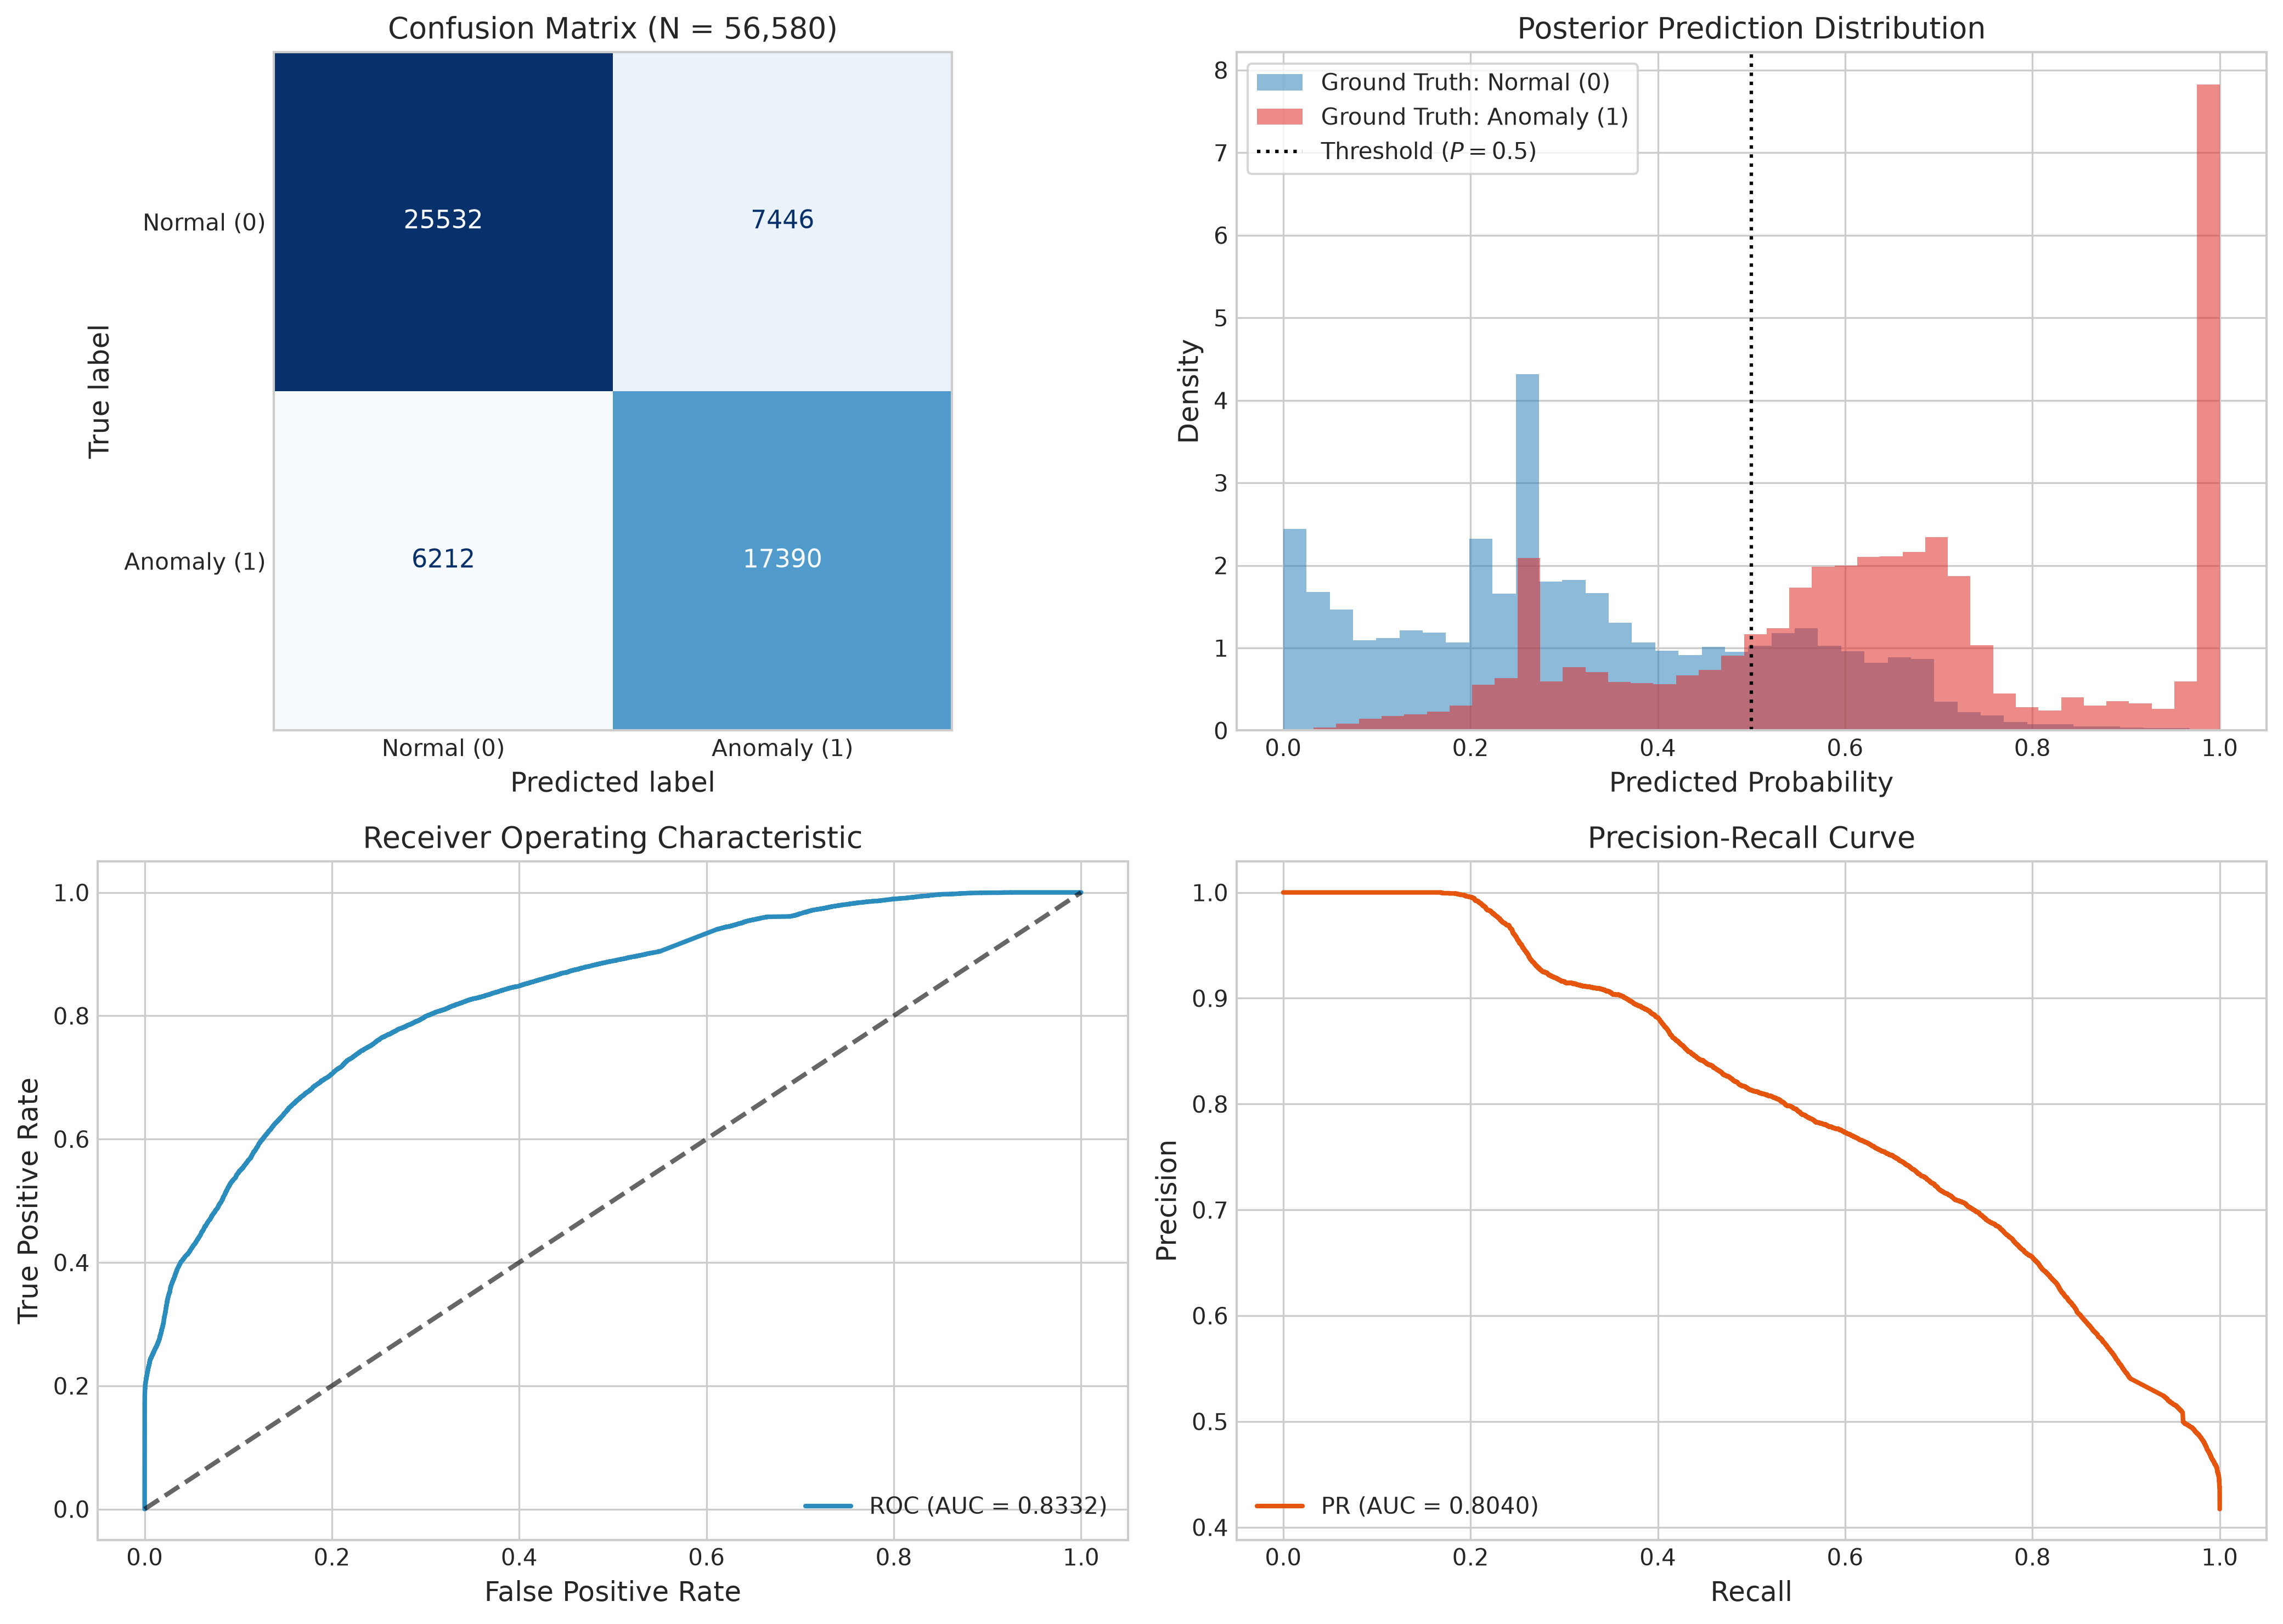

In [101]:
cm = confusion_matrix(df_preds["ground_truth"], df_preds["pred_class"])
fpr, tpr, _ = roc_curve(df_preds["ground_truth"], df_preds["prob_gpu"])
roc_auc = auc(fpr, tpr)
prec, rec, _ = precision_recall_curve(df_preds["ground_truth"], df_preds["prob_gpu"])
pr_auc = average_precision_score(df_preds["ground_truth"], df_preds["prob_gpu"])

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2)

# 1. Confusion Matrix
ax_cm = fig.add_subplot(gs[0, 0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal (0)", "Anomaly (1)"])
disp.plot(ax=ax_cm, cmap="Blues", values_format="d", colorbar=False)
ax_cm.grid(False)
ax_cm.set_title(f"Confusion Matrix (N = {len(df_preds):,})")

# 2. Probability Density (KDE)
ax_kde = fig.add_subplot(gs[0, 1])
p_normal  = df_preds[df_preds["ground_truth"] == 0]["prob_gpu"]
p_anomaly = df_preds[df_preds["ground_truth"] == 1]["prob_gpu"]
ax_kde.hist(p_normal, bins=40, density=True, alpha=0.55, color="#3182bd", label="Ground Truth: Normal (0)")
ax_kde.hist(p_anomaly, bins=40, density=True, alpha=0.55, color="#de2d26", label="Ground Truth: Anomaly (1)")
ax_kde.axvline(0.5, color="black", linestyle=":", linewidth=1.5, label="Threshold ($P=0.5$)")
ax_kde.set_xlabel("Predicted Probability")
ax_kde.set_ylabel("Density")
ax_kde.set_title("Posterior Prediction Distribution")
ax_kde.legend(frameon=True)

# 3. ROC Curve
ax_roc = fig.add_subplot(gs[1, 0])
ax_roc.plot(fpr, tpr, color="#2b8cbe", label=f"ROC (AUC = {roc_auc:.4f})")
ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.6)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("Receiver Operating Characteristic")
ax_roc.legend(loc="lower right")

# 4. PR Curve
ax_pr = fig.add_subplot(gs[1, 1])
ax_pr.plot(rec, prec, color="#e6550d", label=f"PR (AUC = {pr_auc:.4f})")
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-Recall Curve")
ax_pr.legend(loc="lower left")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "09_10_11_ml_evaluation.png"))
plt.show()